In [1]:
import yfinance as yf
import pandas as pd

# Download Data
eog_raw = yf.download("EOG", start="2021-01-01", end="2026-01-01")
cop_raw = yf.download("COP", start="2021-01-01", end="2026-01-01")

# Create a Dataframe
clean_data = pd.DataFrame()
clean_data['EOG'] = eog_raw['Close']
clean_data['COP'] = cop_raw['Close']

# Remove NA Value
clean_data = clean_data.dropna()

print(f"Total trading days captured: {len(clean_data)}")

print(clean_data.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Total trading days captured: 1255
                  EOG        COP
Date                            
2021-01-04  38.504856  32.553257
2021-01-05  41.640232  34.420731
2021-01-06  42.520618  35.794594
2021-01-07  45.269855  36.773575
2021-01-08  45.462914  36.773575


In [2]:
import statsmodels.tsa.stattools as ts

# Separate Companies
asset1 = clean_data['EOG']
asset2 = clean_data['COP']

# Co-Integration Test
score, p_value, critical_values = ts.coint(asset1, asset2)

# Print p_value
print(f"Engle-Granger p-value: {p_value:.4f}")

Engle-Granger p-value: 0.2524


In [4]:
# 1. Download Data 
gld_raw = yf.download("GLD", start="2021-01-01", end="2026-01-01")
slv_raw = yf.download("SLV", start="2021-01-01", end="2026-01-01")

# 2. Create a Dataframe
clean_data = pd.DataFrame()
clean_data['GLD'] = gld_raw['Close']
clean_data['SLV'] = slv_raw['Close']

# 3. Remove NA Values
clean_data = clean_data.dropna()

print(f"Total trading days captured: {len(clean_data)}")
print(clean_data.head())

# 4. Separate Commodities
asset1 = clean_data['GLD']
asset2 = clean_data['SLV']

# 5. Co-Integration Test
score, p_value, critical_values = ts.coint(asset1, asset2)

# 6. Print p_value
print(f"Engle-Granger p-value: {p_value:.4f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Total trading days captured: 1255
                   GLD    SLV
Date                         
2021-01-04  182.330002  25.35
2021-01-05  182.869995  25.67
2021-01-06  179.899994  25.34
2021-01-07  179.479996  25.26
2021-01-08  173.339996  23.51
Engle-Granger p-value: 0.7815


In [6]:
import yfinance as yf
import pandas as pd
import statsmodels.tsa.stattools as ts

# Download Data
googl_raw = yf.download("GOOGL", start="2021-01-01", end="2026-01-01")
goog_raw = yf.download("GOOG", start="2021-01-01", end="2026-01-01")

# Create a Dataframe
clean_data = pd.DataFrame()
clean_data['GOOGL'] = googl_raw['Close']
clean_data['GOOG'] = goog_raw['Close']
clean_data = clean_data.dropna()

print(f"Total trading days captured: {len(clean_data)}")

# Calculate Price Ratio
clean_data['Spread'] = clean_data['GOOGL'] / clean_data['GOOG']

# Augmented Dickey-Fuller Test
adf_result = ts.adfuller(clean_data['Spread'])
p_value = adf_result[1]

# 5. Print p_value
print(f"Spread Stationarity (ADF) p-value: {p_value:.4f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Total trading days captured: 1255
Spread Stationarity (ADF) p-value: 0.0036


In [17]:
# Rolling Window
window = 30

# 30-day Moving Average and Standard Deviation
clean_data['Moving_Avg'] = clean_data['Spread'].rolling(window=window).mean()
clean_data['Moving_Std'] = clean_data['Spread'].rolling(window=window).std()

# Calculate the Z-Score
clean_data['Z_Score'] = (clean_data['Spread'] - clean_data['Moving_Avg']) / clean_data['Moving_Std']

# Remove NA Value
trading_data = clean_data.dropna().copy()

# Trading Logic 
def generate_signal(z):
    if z < -2.0:
        return "BUY"
    elif z > 2.0:
        return "SELL"
    else:
        return "HOLD"

# Apply logic 
trading_data['Signal'] = trading_data['Z_Score'].apply(generate_signal)

# Test
print("\n--- Recent Market Signals ---")
print(trading_data[['Spread', 'Z_Score', 'Signal']].tail(30))


--- Recent Market Signals ---
              Spread   Z_Score Signal
Date                                 
2025-11-18  0.997617 -0.031394   HOLD
2025-11-19  0.999389  2.261689   SELL
2025-11-20  0.998176  0.562551   HOLD
2025-11-21  1.000037  2.763751   SELL
2025-11-24  1.000349  2.653413   SELL
2025-11-25  0.999385  1.461768   HOLD
2025-11-26  0.998973  0.944532   HOLD
2025-11-28  1.000191  2.039960   SELL
2025-12-01  0.999274  1.051920   HOLD
2025-12-02  0.999339  1.056445   HOLD
2025-12-03  0.996916 -1.335393   HOLD
2025-12-04  0.997585 -0.728255   HOLD
2025-12-05  0.997457 -0.860401   HOLD
2025-12-08  0.997684 -0.625216   HOLD
2025-12-09  0.997896 -0.421192   HOLD
2025-12-10  0.997544 -0.873705   HOLD
2025-12-11  0.995957 -2.305219    BUY
2025-12-12  0.996044 -1.983038   HOLD
2025-12-15  0.996449 -1.508700   HOLD
2025-12-16  0.996236 -1.559942   HOLD
2025-12-17  0.995509 -1.953798   HOLD
2025-12-18  0.995758 -1.610613   HOLD
2025-12-19  0.995307 -1.775555   HOLD
2025-12-22  0.99502

In [8]:
# 1. Convert Text Signals Numbers
def position_math(signal):
    if signal == 'BUY':
        return 1
    elif signal == 'SELL':
        return -1
    else:
        return 0

trading_data['Position'] = trading_data['Signal'].apply(position_math)

# 2. Daily Change
trading_data['Spread_Return'] = trading_data['Spread'].pct_change()

# 3. Calculate Return
trading_data['Strategy_Return'] = trading_data['Position'].shift(1) * trading_data['Spread_Return']

# 4. Calculate total profit (starting with $1.00)
trading_data['Cumulative_Profit'] = (1 + trading_data['Strategy_Return'].fillna(0)).cumprod()

# 5. Print Final ROI
final_return_percentage = (trading_data['Cumulative_Profit'].iloc[-1] - 1) * 100
print(f"\nTotal Strategy Return: {final_return_percentage:.2f}%")


Total Strategy Return: 10.96%


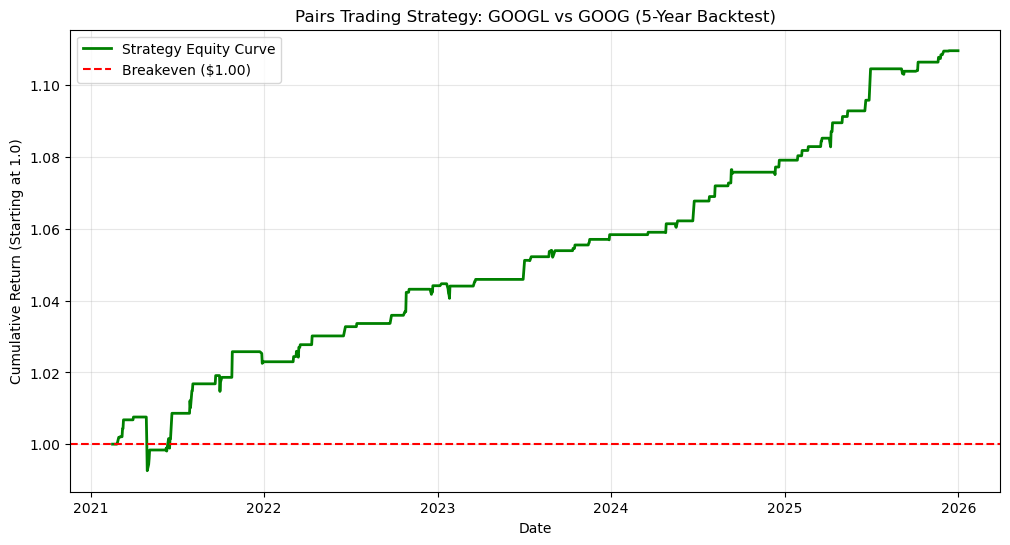

In [9]:
import matplotlib.pyplot as plt

# Size
plt.figure(figsize=(12, 6))

# Plot Profit
plt.plot(trading_data.index, trading_data['Cumulative_Profit'], label='Strategy Equity Curve', color='green', linewidth=2)

# Baseline
plt.axhline(1.0, color='red', linestyle='--', label='Breakeven ($1.00)')

# Titles
plt.title('Pairs Trading Strategy: GOOGL vs GOOG (5-Year Backtest)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Starting at 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)

# Display Chart
plt.show()